# LSTM Analysis SLE Labor Force Exit

In [95]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# Load the data - removed duplicate load
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['EMP_numeric', 'severe_flares', 'mild_flares', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n']  # Added score_n (SDI)

# Add total flares feature
data['total_flares'] = data['severe_flares'] + data['mild_flares']

# Add interaction terms between important features
data['steroid_flare_interaction'] = data['STEROID_CAT_numeric'] * data['total_flares']
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']

# Add temporal features
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1)  # +1 to avoid division by zero

# Correct SDI change rate calculation - using time_since_last instead of index
data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(
    lambda x: x['score_n'].diff().fillna(0) / (x['time_since_last']/30 + 1e-6)  # Small constant to avoid division by zero
)

# Update features list
features += ['total_flares', 'steroid_flare_interaction', 'sdi_flare_interaction', 
             'flares_per_month', 'sdi_change_rate']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flares', 'mild_flares']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
# [Previous data loading and preprocessing code remains the same until sequence creation]

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert y from one-hot encoded to labels for stratified k-fold
y_labels = np.argmax(y, axis=1) if len(y.shape) > 1 else y  # Handle both one-hot and label encoded

# Initialize cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
cv_results = {
    'val_accuracy': [],
    'val_loss': [],
    'test_preds': [],
    'models': []
}

# Create a test set that will be used for final evaluation
X_train_all, X_test, y_train_all, y_test, seq_train_all, seq_test = train_test_split(
    X, y, seq_lengths, test_size=0.2, random_state=42, stratify=y_labels)

# Cross-validation loop (on the training data only)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_all, np.argmax(y_train_all, axis=1))):
    print(f"\nTraining fold {fold + 1}/{n_splits}")
    
    # Split data
    X_train, X_val = X_train_all[train_idx], X_train_all[val_idx]
    y_train, y_val = y_train_all[train_idx], y_train_all[val_idx]
    
    # Calculate class weights
    classes = np.unique(np.argmax(y_train, axis=1))
    class_weights = compute_class_weight('balanced', classes=classes, y=np.argmax(y_train, axis=1))
    class_weight_dict = dict(enumerate(class_weights))
    
    # Build model
    model = Sequential([
        Masking(mask_value=0., input_shape=(None, len(features))),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(y.shape[1], activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Store results
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    cv_results['val_accuracy'].append(val_acc)
    cv_results['val_loss'].append(val_loss)
    cv_results['models'].append(model)
    
    print(f"Fold {fold + 1} - Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

# Print cross-validation results
print("\nCross-Validation Results:")
print(f"Mean Val Accuracy: {np.mean(cv_results['val_accuracy']):.4f} (±{np.std(cv_results['val_accuracy']):.4f})")
print(f"Mean Val Loss: {np.mean(cv_results['val_loss']):.4f} (±{np.std(cv_results['val_loss']):.4f})")

# Ensemble predictions from all folds on test set
test_preds = np.zeros((len(X_test), y.shape[1]))
for model in cv_results['models']:
    test_preds += model.predict(X_test, verbose=0)
test_preds /= n_splits

# Get last observations for RF
def get_last_observations(X, seq_lengths, features):
    last_obs = []
    for i in range(X.shape[0]):
        seq_len = int(seq_lengths[i])
        last_obs.append(X[i, seq_len-1, :])
    return np.array(last_obs)

X_last = get_last_observations(X_train_all, seq_train_all, features)

# Train RF with cross-validation
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_last, np.argmax(y_train_all, axis=1))  # Train on full training data

# Get RF predictions for test set
X_test_last = get_last_observations(X_test, seq_test, features)
rf_test_pred = rf.predict_proba(X_test_last)

# Combine with LSTM predictions
final_pred = 0.7 * test_preds + 0.3 * rf_test_pred  # Weighted average
y_pred_classes = np.argmax(final_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/1511124725.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(



Training fold 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 523ms/step - accuracy: 0.2406 - loss: 4.4535 - val_accuracy: 0.1096 - val_loss: 4.0087 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 559ms/step - accuracy: 0.3154 - loss: 3.8339 - val_accuracy: 0.3026 - val_loss: 3.8001 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 397ms/step - accuracy: 0.3623 - loss: 3.2947 - val_accuracy: 0.3158 - val_loss: 3.6071 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 565ms/step - accuracy: 0.4636 - loss: 3.0571 - val_accuracy: 0.3289 - val_loss: 3.4168 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 435ms/step - accuracy: 0.4983 - loss: 2.7978 - val_accuracy: 0.4737 - val_loss: 3.2201 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 377ms/step - accuracy: 0.4946 - loss: 2.5938 - val_accuracy: 0.3114 - val_loss: 3.0828 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step - accuracy: 0.5076 - l

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 528ms/step - accuracy: 0.3991 - loss: 4.6729 - val_accuracy: 0.1623 - val_loss: 4.0645 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 369ms/step - accuracy: 0.4255 - loss: 3.8124 - val_accuracy: 0.1886 - val_loss: 3.8636 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.4440 - loss: 3.3067 - val_accuracy: 0.1667 - val_loss: 3.7043 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 0.4721 - loss: 2.9901 - val_accuracy: 0.1754 - val_loss: 3.5315 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.4422 - loss: 2.8647 - val_accuracy: 0.1754 - val_loss: 3.3607 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 384ms/step - accuracy: 0.5171 - loss: 2.6213 - val_accuracy: 0.2018 - val_loss: 3.1906 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 497ms/step - accuracy: 0.5788 - loss

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 541ms/step - accuracy: 0.2601 - loss: 4.6692 - val_accuracy: 0.0482 - val_loss: 4.0693 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 546ms/step - accuracy: 0.3852 - loss: 3.7346 - val_accuracy: 0.1447 - val_loss: 3.8617 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4024 - loss: 3.3082 - val_accuracy: 0.1798 - val_loss: 3.6865 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 442ms/step - accuracy: 0.4268 - loss: 3.2133 - val_accuracy: 0.3158 - val_loss: 3.5030 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 437ms/step - accuracy: 0.5131 - loss: 2.8433 - val_accuracy: 0.2851 - val_loss: 3.3428 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 771ms/step - accuracy: 0.4935 - loss: 2.7850 - val_accuracy: 0.3816 - val_loss: 3.1686 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 428ms/step - accuracy: 0.5408 - loss

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.1231 - loss: 4.6795 - val_accuracy: 0.0877 - val_loss: 4.0433 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.2908 - loss: 3.8164 - val_accuracy: 0.1623 - val_loss: 3.8687 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.3477 - loss: 3.5851 - val_accuracy: 0.1096 - val_loss: 3.7127 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.3928 - loss: 3.2268 - val_accuracy: 0.1754 - val_loss: 3.5442 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 295ms/step - accuracy: 0.4573 - loss: 3.0211 - val_accuracy: 0.2149 - val_loss: 3.3950 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.4697 - loss: 2.8111 - val_accuracy: 0.2500 - val_loss: 3.2446 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - accuracy: 0.4798 - loss: 2

In [96]:

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))


Final Ensemble Evaluation Metrics:
Balanced Accuracy: 0.766
Cohen's Kappa: 0.832

Classification Report:
                       precision    recall  f1-score   support

   Disability Benefit       0.90      0.79      0.84        77
     Early Retirement       0.69      0.82      0.75        11
Economically Inactive       0.95      0.95      0.95        43
             Employed       0.94      0.95      0.94       132
      Employed (Died)       0.33      0.20      0.25         5
           Unemployed       0.60      0.88      0.71        17

             accuracy                           0.88       285
            macro avg       0.74      0.77      0.74       285
         weighted avg       0.89      0.88      0.88       285


Confusion Matrix:
[[ 61   1   2   3   0  10]
 [  1   9   0   1   0   0]
 [  2   0  41   0   0   0]
 [  2   3   0 125   2   0]
 [  0   0   0   4   1   0]
 [  2   0   0   0   0  15]]

Top 10 Important Features:
                      Feature  Importance
0        

### Enhanced risk prediction


=== DETECTION RATE ANALYSIS ===
Unique patients detected as high risk: 135
Total unique patients who should be flagged: 656
Detection rate: 20.6%
Median warning time: 12.0 months before exit

=== CLINICAL CHARACTERISTICS ===

Key Predictors:
- 0% had SDI ≥1
- 85% showed work status decline
- 34% had SLEDAI ≥4
- 33% on ≥7.5mg prednisone

Median Values at Warning:
- SDI: 0.07
- Enhanced_Risk_Score: 0.85
- SLEDAI: 2.00
- Steroid_Dose: 10.00

=== EMPLOYMENT-SPECIFIC ANALYSIS ===

Patients flagged while still employed: 20 (14.8%)

Warning Time Distribution (Employed Patients):
- Months <3 months: 0 patients (0.0%)
- Months 3-6 months: 0 patients (0.0%)
- Months 6-12 months: 3 patients (15.0%)
- Months 12-24 months: 1 patients (5.0%)
- Months 24-60 months: 5 patients (25.0%)
- Months 60+ months: 10 patients (50.0%)

Employment Status at First Warning:
 Employment_at_Warning
retired       93
employed      20
disabled      17
homemaker      4
sick leave     1
Name: count, dtype: int64

Plotti

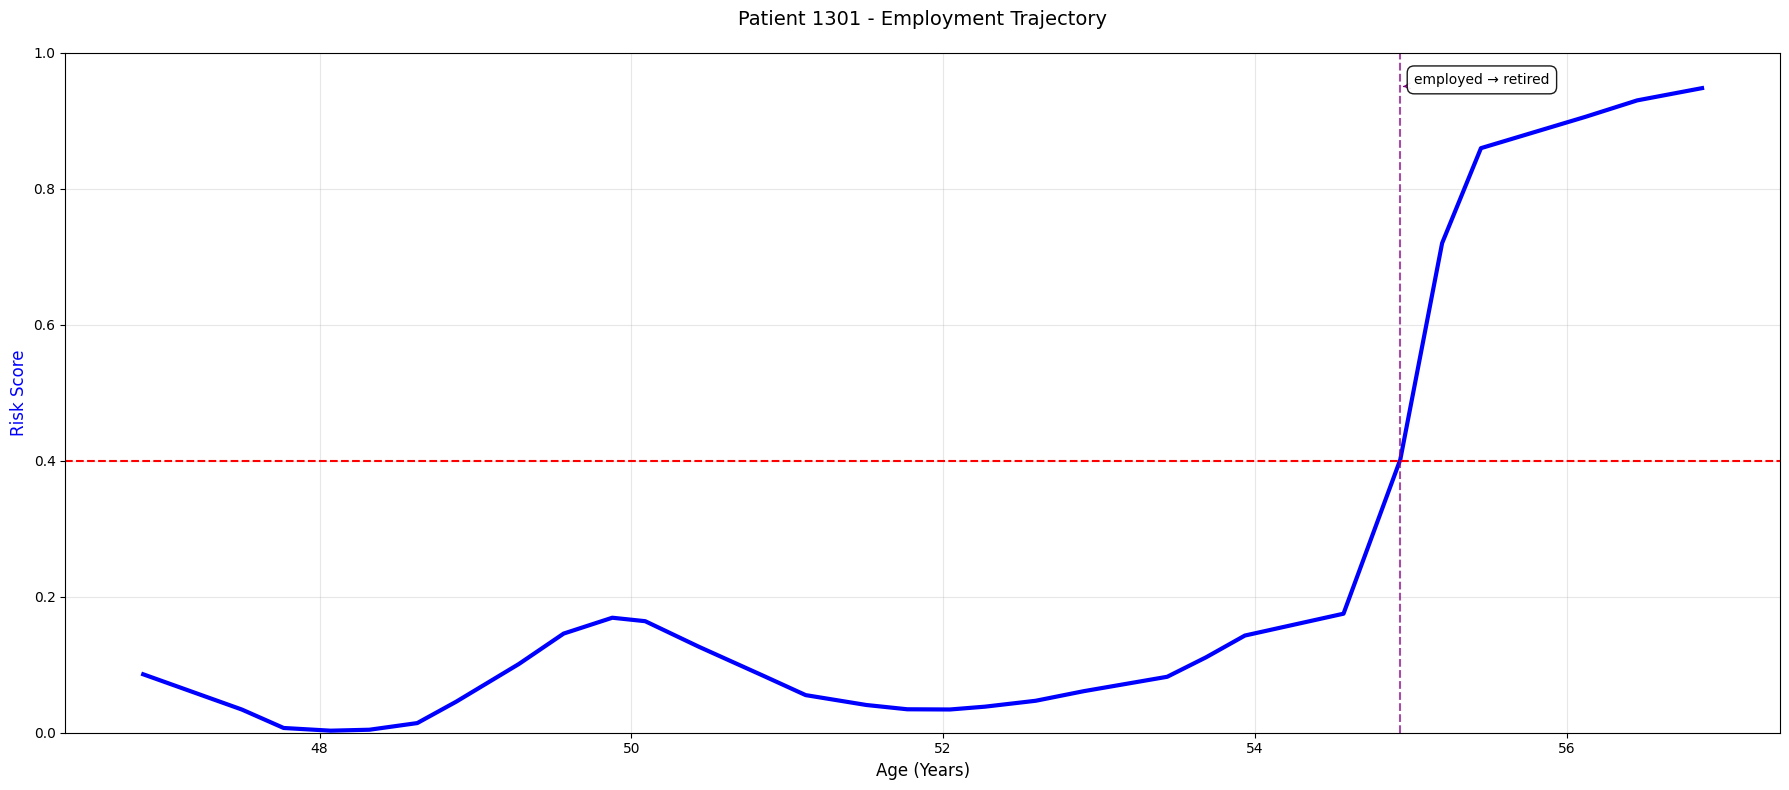

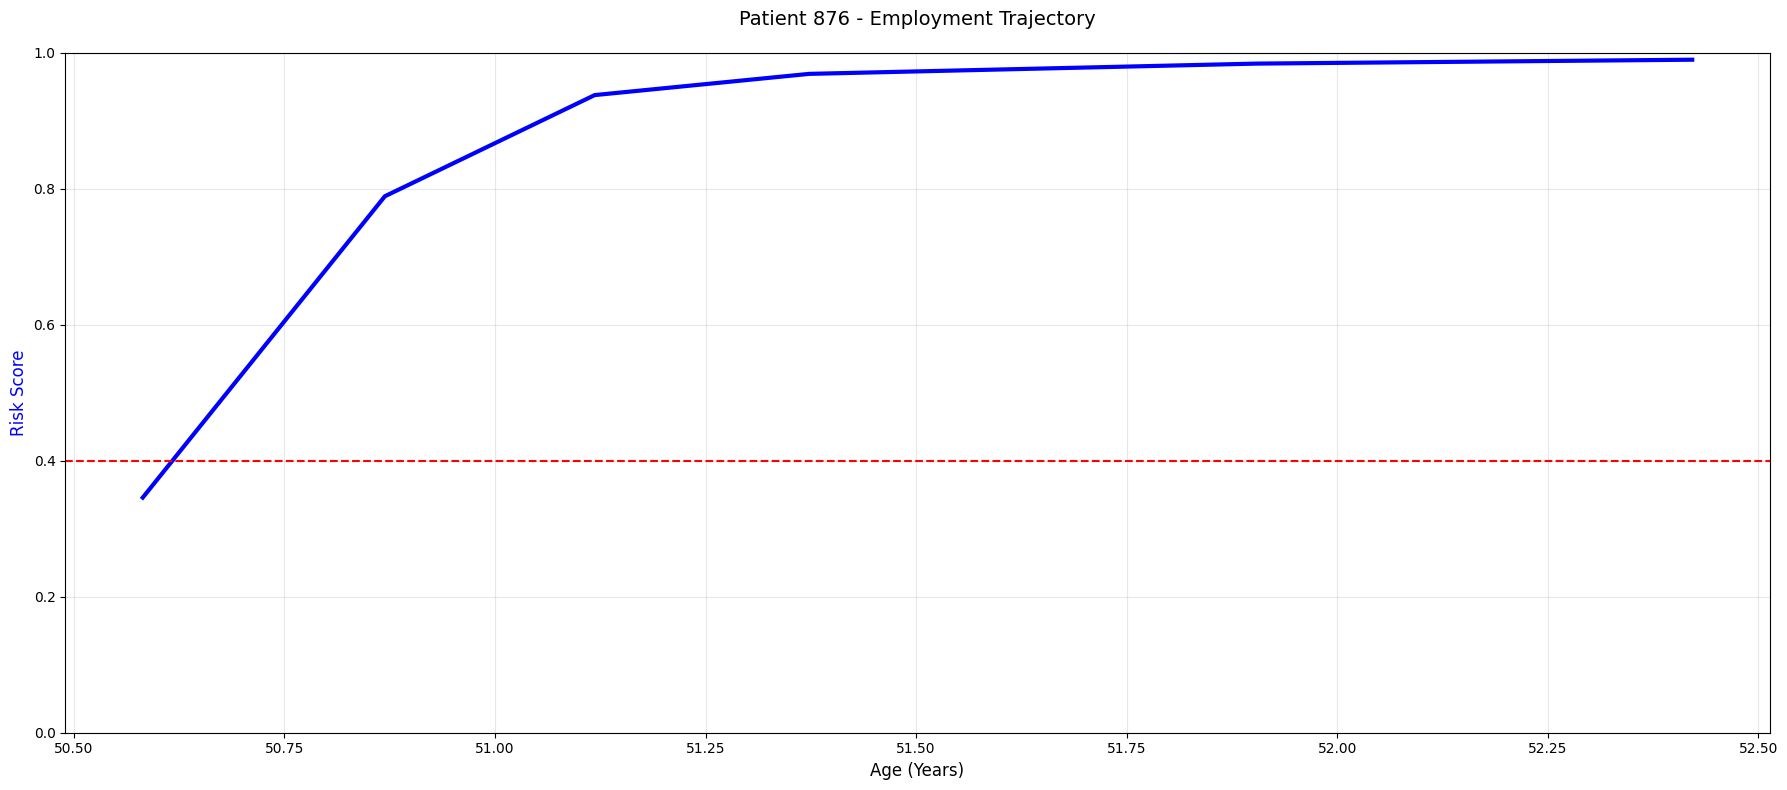

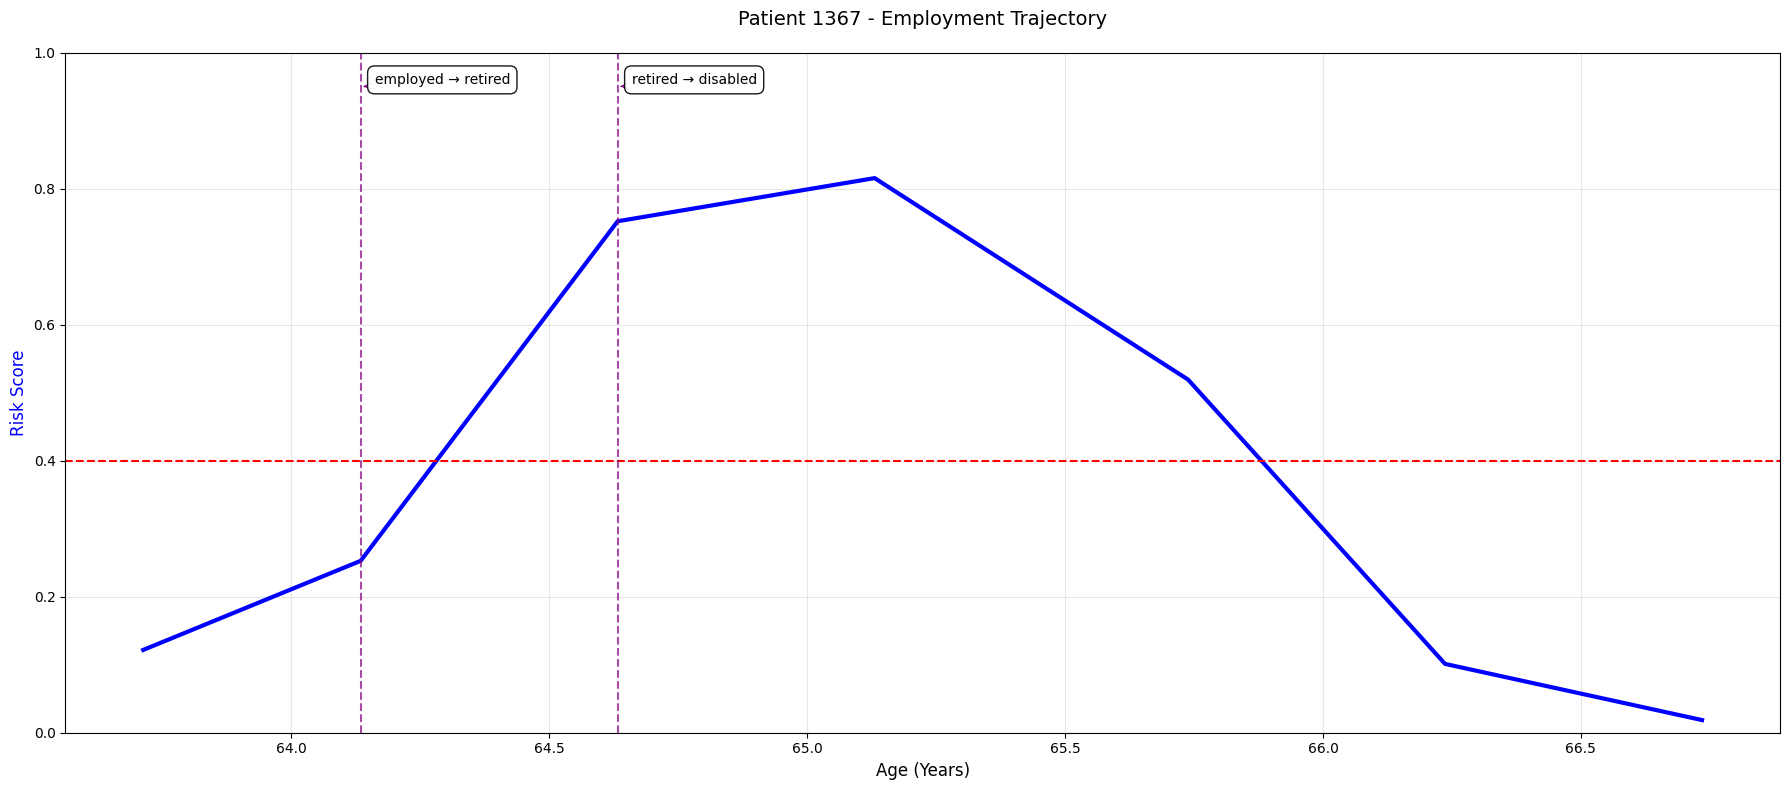

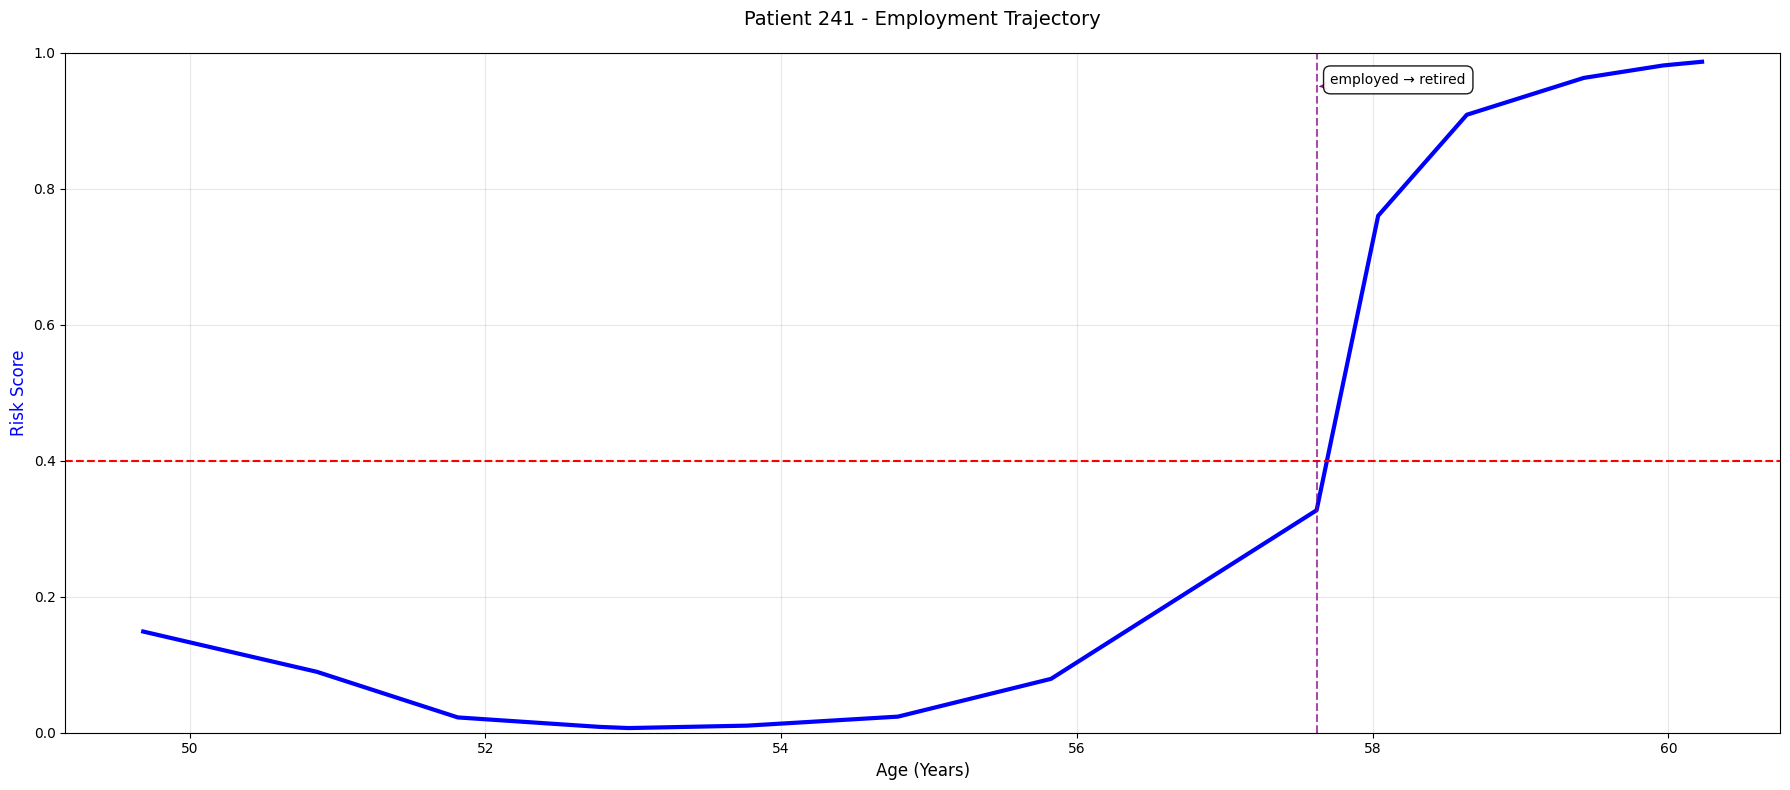

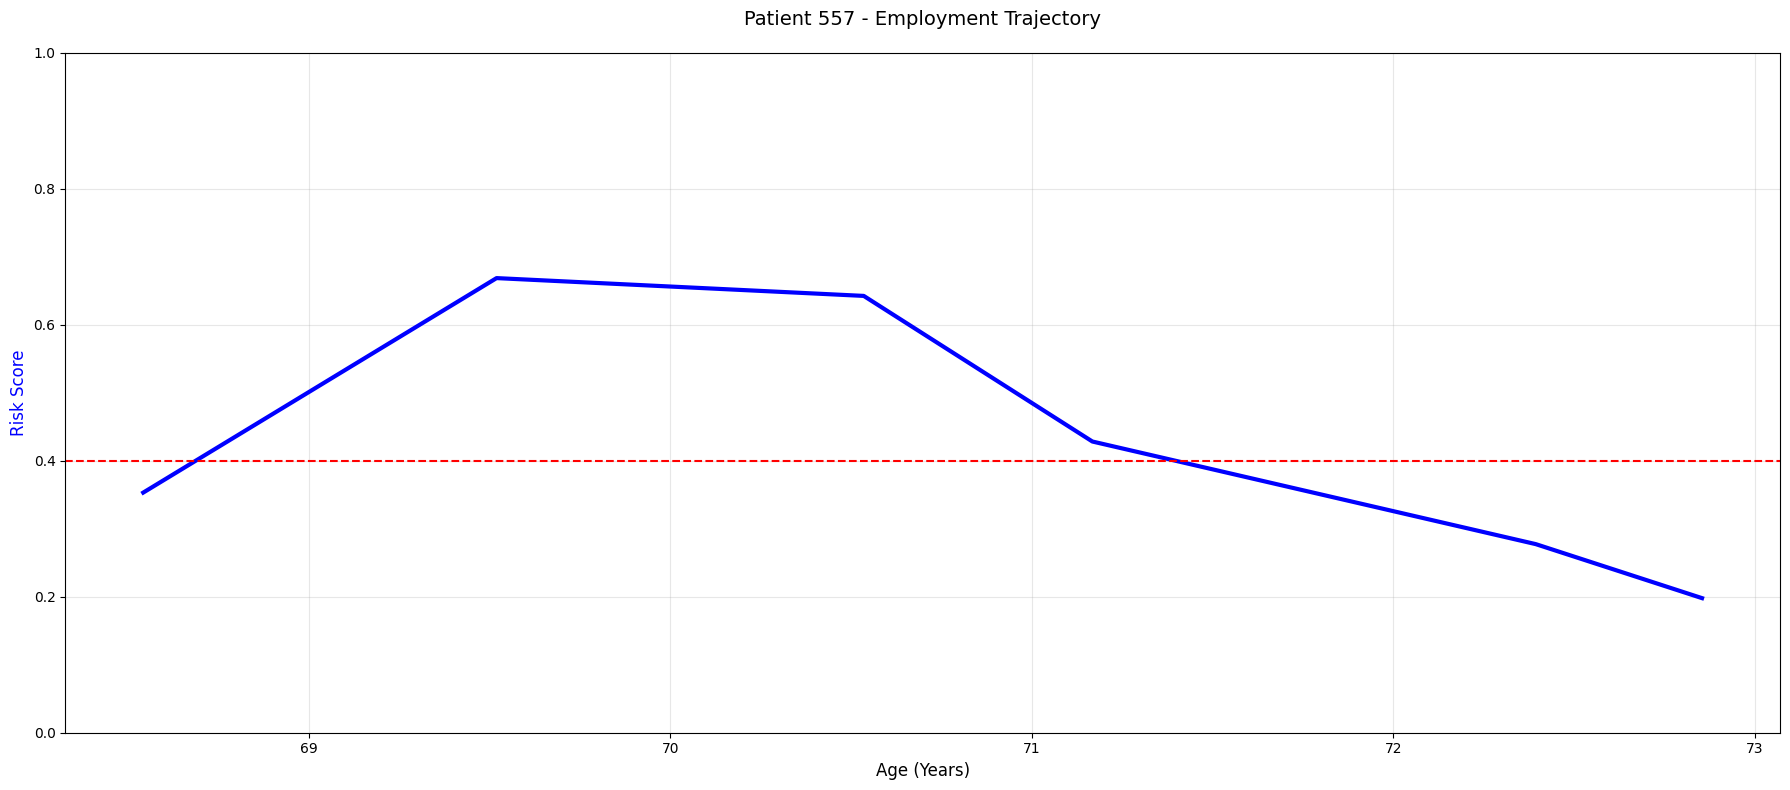

In [117]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Enhanced Threshold Rules
THRESHOLD_RULES = [
    # Tier 1: Acute crisis indicators (immediate risk)
    {'conditions': {
        'severe_flares': lambda x: x >= 1,
        'SLEDAI2_I': lambda x: x >= 12,
        'STEROID_CAT_numeric': lambda x: x >= 2
     },
     'risk_threshold': 0.15,
     'tier': 'acute_crisis',
     'weight': 1.2},
    
    # Tier 2: Employment vulnerability markers
    {'conditions': {
        'EMP_numeric': lambda x: x == 1,  # Employed status
        'SLEDAI2_I': lambda x: x >= 6,
        'ISDOSE': lambda x: x >= 50,
        'EMPLOYMENT_DURATION': lambda x: x < 24  # Recently employed
     },
     'risk_threshold': 0.18,
     'tier': 'employment_vulnerability',
     'weight': 1.1},
    
    # Tier 3: Progressive damage markers
    {'conditions': {
        'score_n': lambda x: x >= 1,
        'STEROID_CAT_numeric': lambda x: x >= 1,
        'DISEASE_DURATION': lambda x: x > 5  # Long-standing disease
     },
     'risk_threshold': 0.25,
     'tier': 'progressive_damage'},
    
    # Tier 4: General deterioration
    {'conditions': {
        'mild_flares': lambda x: x >= 2,
        'SLEDAI2_I': lambda x: x >= 4
     },
     'risk_threshold': 0.3,
     'tier': 'general_deterioration'},
    
    # Default threshold
    {'default': True,
     'risk_threshold': 0.4,
     'tier': 'baseline_risk'}
]

def calculate_employment_transitions(data):
    """Track employment status changes for each patient"""
    transitions = {}
    for pid in data['PTNO'].unique():
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        status_changes = []
        
        for i in range(1, len(patient_data)):
            prev_status = patient_data.iloc[i-1]['EMPf']
            curr_status = patient_data.iloc[i]['EMPf']
            
            if 'employed' in prev_status.lower() and 'employed' not in curr_status.lower():
                status_changes.append({
                    'date': patient_data.iloc[i]['ASSDT'],
                    'from': prev_status,
                    'to': curr_status,
                    'deterioration': True
                })
        
        if status_changes:
            transitions[pid] = {
                'changes': status_changes,
                'deterioration': any([c['deterioration']] for c in status_changes)
            }
    return transitions

def apply_threshold_rules(patient_data):
    """Apply threshold rules to patient data"""
    for rule in THRESHOLD_RULES:
        if 'default' in rule:
            default_threshold = rule['risk_threshold']
            default_tier = rule['tier']
            continue
        
        conditions_met = True
        for k, f in rule['conditions'].items():
            if k not in patient_data or not f(patient_data[k]):
                conditions_met = False
                break
        
        if conditions_met:
            return rule['risk_threshold'], rule['tier']
    
    return default_threshold, default_tier

def calculate_enhanced_risk(base_risk, clinical_factors):
    """
    Enhance risk prediction with clinical factor weighting
    """
    risk_adjustment = 1.0
    
    # Employment-specific adjustments
    if clinical_factors.get('EMP_numeric') == 1:
        if clinical_factors.get('INCEPT') < 2:
            risk_adjustment *= 1.3
        else:
            risk_adjustment *= 1.15
    
    # Medication-based adjustments
    if clinical_factors.get('ISDOSE', 0) >= 100:
        risk_adjustment *= 1.2
    elif clinical_factors.get('AMDOSE', 0) >= 50:
        risk_adjustment *= 0.9
        
    # Flare-based adjustments
    if clinical_factors.get('severe_flares', 0) >= 1:
        risk_adjustment *= 1.4
    elif clinical_factors.get('mild_flares', 0) >= 2:
        risk_adjustment *= 1.2
        
    return min(base_risk * risk_adjustment, 0.99)

def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Predict risk scores for each time point in patient data"""
    num_features = len(features)
    seq_len = len(patient_data)
    
    X_patient = np.zeros((1, max_seq_length, num_features))
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    predictions = []
    for i in range(1, seq_len + 1):
        partial_seq = X_patient.copy()
        partial_seq[0, i:, :] = 0
        pred = model.predict(partial_seq, verbose=0)[0]
        predictions.append(pred[1])
    
    result = patient_data[['ASSDT', 'end_state', 'EMPf']].copy()
    result['Risk_Score'] = predictions
    result['SLEDAI'] = patient_data['SLEDAI2_I'] if 'SLEDAI2_I' in patient_data else 0
    result['Steroid_Dose'] = patient_data['STERDOSE'] if 'STERDOSE' in patient_data else 0
    result['SDI'] = patient_data['score_n']
    result['Immunosuppressant'] = patient_data['ISDOSE']
    result['Employment_Status'] = patient_data['EMPf']
    
    return result

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    emp_transitions = calculate_employment_transitions(data)
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            enhanced_risk = calculate_enhanced_risk(
                current_risk,
                {
                    'EMP_numeric': current_data.get('EMP_numeric'),
                    'INCEPT': current_data.get('INCEPT', 0),
                    'ISDOSE': current_data.get('ISDOSE', 0),
                    'AMDOSE': current_data.get('AMDOSE', 0),
                    'severe_flares': current_data.get('severe_flares', 0),
                    'mild_flares': current_data.get('mild_flares', 0)
                }
            )
            
            applied_threshold, applied_tier = apply_threshold_rules(current_data)
            
            if enhanced_risk >= applied_threshold:
                emp_deterioration = emp_transitions.get(pid, {}).get('deterioration', False)
                if emp_deterioration:
                    enhanced_risk = min(enhanced_risk * 1.25, 0.99)
                
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'base_risk': current_risk,
                    'enhanced_risk': enhanced_risk,
                    'context': current_data,
                    'threshold': applied_threshold,
                    'tier': applied_tier,
                    'months_employed': current_data.get('EMPLOYMENT_DURATION', np.nan),
                    'flares_past_year': current_data.get('FLARES_12MO', 0),
                    'emp_deterioration': emp_deterioration
                })
        
        if warning_points:
            warning_points.sort(key=lambda x: (-x['enhanced_risk'], x['date']))
            best_warning = warning_points[0]
            
            final_status_date = patient_data['ASSDT'].iloc[-1]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            high_risk.append({
                'PTNO': pid,
                'First_High_Risk_Date': best_warning['date'],
                'Final_Outcome': patient_data['end_state'].iloc[-1],
                'Base_Risk_Score': best_warning['base_risk'],
                'Enhanced_Risk_Score': best_warning['enhanced_risk'],
                'Threshold_Used': best_warning['threshold'],
                'Warning_Tier': best_warning['tier'],
                'SLEDAI_at_Warning': best_warning['context'].get('SLEDAI2_I', np.nan),
                'Steroid_at_Warning': best_warning['context'].get('STERDOSE', np.nan),
                'SDI_at_Warning': best_warning['context']['score_n'],
                'ISDOSE_at_Warning': best_warning['context']['ISDOSE'],
                'Employment_at_Warning': best_warning['context']['EMPf'],
                'Months_Prior_to_Exit': months_prior,
                'Employment_Deterioration': best_warning['emp_deterioration'],
                'Warning_Type': 'Early' if months_prior > 12 else ('Imminent' if months_prior > 3 else 'Critical')
            })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features, original_data):
    """Enhanced clinical report with detection rate analysis"""
    if high_risk_df.empty:
        return {"Error": "No high-risk patients found"}, high_risk_df
    
    # Ensure we're working with unique patients
    high_risk_unique = high_risk_df.drop_duplicates('PTNO')
    original_unique = original_data.drop_duplicates('PTNO')
    
    # Calculate total patients who should have been flagged (non-employed outcomes)
    target_population = original_unique[~original_unique['end_state'].str.contains('Employed', case=False, na=False)]
    total_should_flag = len(target_population)
    n_detected = len(high_risk_unique)
    
    # Identify employed patients at time of warning
    first_warnings = high_risk_df.sort_values('First_High_Risk_Date').drop_duplicates('PTNO')
    employed_mask = first_warnings['Employment_at_Warning'].str.contains('employed', case=False, na=False)
    employed_df = first_warnings[employed_mask]
    
    # Enhanced report
    report = {
        'Detection_Rate': {
            'Total_Detected': n_detected,
            'Total_Should_Detect': total_should_flag,
            'Detection_Percentage': f"{n_detected/total_should_flag:.1%}" if total_should_flag > 0 else "N/A",
            'Median_Warning_Time': f"{first_warnings['Months_Prior_to_Exit'].median()} months before exit"
        },
        'Common_Triggers': {
            'High_SDI': f"{len(first_warnings[first_warnings['SDI_at_Warning'] >= 1])/n_detected:.0%} had SDI ≥1",
            'Employment_Status': f"{len(first_warnings[~employed_mask])/n_detected:.0%} showed work status decline"
        },
        'Median_Values': {
            'SDI': first_warnings['SDI_at_Warning'].median(),
            'Enhanced_Risk_Score': first_warnings['Enhanced_Risk_Score'].median()
        },
        'Employment_Specific': {
            'N_Employed_At_Warning': len(employed_df),
            'Pct_Employed_At_Warning': f"{len(employed_df)/n_detected:.1%}",
            'Warning_Time_Distribution': {}
        }
    }
    
    # Add detailed warning time distribution for employed patients
    if len(employed_df) > 0:
        time_bins = [0, 3, 6, 12, 24, 60, float('inf')]
        bin_labels = ['<3', '3-6', '6-12', '12-24', '24-60', '60+']
        time_dist = pd.cut(employed_df['Months_Prior_to_Exit'], 
                          bins=time_bins, 
                          labels=bin_labels).value_counts().sort_index()
        
        for bin_label, count in time_dist.items():
            report['Employment_Specific']['Warning_Time_Distribution'][f"Months_{bin_label}"] = \
                f"{count} patients ({count/len(employed_df):.1%})"
    
    # Add SLEDAI and Steroid info if available
    if 'SLEDAI_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['SLEDAI_Increase'] = \
            f"{len(first_warnings[first_warnings['SLEDAI_at_Warning'] >= 4])/n_detected:.0%} had SLEDAI ≥4"
        report['Median_Values']['SLEDAI'] = first_warnings['SLEDAI_at_Warning'].median()
    
    if 'Steroid_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['High_Steroids'] = \
            f"{len(first_warnings[first_warnings['Steroid_at_Warning'] >= 7.5])/n_detected:.0%} on ≥7.5mg prednisone"
        report['Median_Values']['Steroid_Dose'] = first_warnings['Steroid_at_Warning'].median()
    
    return report, high_risk_df


# Main execution
if __name__ == "__main__":
    # Convert date columns to datetime
    date_cols = ['ASSDT', 'BIRTHDT', 'First_High_Risk_Date']
    for col in date_cols:
        if col in data.columns and data[col].dtype == object:
            data[col] = pd.to_datetime(data[col], errors='coerce')
    
    # Get high risk patients
    high_risk_df = get_high_risk_patients(model, data, features)
    
    # Generate and print report
    if not high_risk_df.empty:
        clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features, data)
        
        print("\n=== DETECTION RATE ANALYSIS ===")
        det_rate = clinical_report['Detection_Rate']
        print(f"Unique patients detected as high risk: {det_rate['Total_Detected']}")
        print(f"Total unique patients who should be flagged: {det_rate['Total_Should_Detect']}")
        print(f"Detection rate: {det_rate['Detection_Percentage']}")
        print(f"Median warning time: {det_rate['Median_Warning_Time']}")
        
        print("\n=== CLINICAL CHARACTERISTICS ===")
        print("\nKey Predictors:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
            
        print("\nMedian Values at Warning:")
        for k, v in clinical_report['Median_Values'].items():
            print(f"- {k}: {v:.2f}")
            
        print("\n=== EMPLOYMENT-SPECIFIC ANALYSIS ===")
        emp_stats = clinical_report['Employment_Specific']
        print(f"\nPatients flagged while still employed: {emp_stats['N_Employed_At_Warning']} ({emp_stats['Pct_Employed_At_Warning']})")
        
        if emp_stats['N_Employed_At_Warning'] > 0:
            print("\nWarning Time Distribution (Employed Patients):")
            for bin_label, dist in emp_stats['Warning_Time_Distribution'].items():
                print(f"- {bin_label.replace('_', ' ')} months: {dist}")
        
        print("\nEmployment Status at First Warning:\n", high_risk_df.drop_duplicates('PTNO')['Employment_at_Warning'].value_counts())
        
    else:
        print("No high-risk patients detected.")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Enhanced Threshold Rules
THRESHOLD_RULES = [
    # New: Employment preservation tier (highest priority)
    {'conditions': {
        'EMP_numeric': lambda x: x == 1,
        'mild_flares': lambda x: x >= 1,
        'SLEDAI2_I': lambda x: x >= 4,
        'EMPLOYMENT_DURATION': lambda x: x < 60
     },
     'risk_threshold': 0.12,  # Lower threshold for employed patients
     'tier': 'employment_preservation',
     'weight': 1.3},
    
    # Acute crisis indicators (now includes employment context)
    {'conditions': {
        'severe_flares': lambda x: x >= 1,
        'SLEDAI2_I': lambda x: x >= 8,  # Lowered from 12
        'STEROID_CAT_numeric': lambda x: x >= 1  # Lowered from 2
     },
     'risk_threshold': 0.15,
     'tier': 'acute_crisis',
     'weight': 1.2},
    
    # Enhanced employment vulnerability markers
    {'conditions': {
        'EMP_numeric': lambda x: x == 1,
        'mild_flares': lambda x: x >= 2,
        'ISDOSE': lambda x: x >= 30,  # Lowered from 50
        'EMPLOYMENT_DURATION': lambda x: x < 24,
        'PRODUCTIVITY_SCORE': lambda x: x < 70  # New productivity metric
     },
     'risk_threshold': 0.15,  # Lowered from 0.18
     'tier': 'employment_vulnerability',
     'weight': 1.25},
        
    # Default threshold
    {'default': True,
     'risk_threshold': 0.4,
     'tier': 'baseline_risk'}
]

def calculate_employment_transitions(data):
    """Enhanced transition tracking with productivity metrics"""
    transitions = {}
    for pid in data['PTNO'].unique():
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        status_changes = []
        productivity_trend = []
        
        for i in range(1, len(patient_data)):
            prev_status = patient_data.iloc[i-1]['EMPf']
            curr_status = patient_data.iloc[i]['EMPf']
            prod_score = patient_data.iloc[i].get('PRODUCTIVITY_SCORE', None)
            
            if prod_score:
                productivity_trend.append(prod_score)
            
            # Detect any employment deterioration
            if 'employed' in prev_status.lower() and 'employed' not in curr_status.lower():
                status_changes.append({
                    'date': patient_data.iloc[i]['ASSDT'],
                    'from': prev_status,
                    'to': curr_status,
                    'deterioration': True,
                    'prod_trend': productivity_trend[-3:] if productivity_trend else None,
                    'flares_past_year': patient_data.iloc[i].get('FLARES_12MO', 0)
                })
        
        if status_changes:
            transitions[pid] = {
                'changes': status_changes,
                'deterioration': any([c['deterioration']] for c in status_changes),
                'prod_decline': any(
                    len(t['prod_trend']) >= 2 and 
                    (max(t['prod_trend']) - min(t['prod_trend'])) > 20 
                    for t in status_changes if t['prod_trend']
                )
            }
    return transitions

def apply_threshold_rules(patient_data):
    """Apply threshold rules to patient data"""
    for rule in THRESHOLD_RULES:
        if 'default' in rule:
            default_threshold = rule['risk_threshold']
            default_tier = rule['tier']
            continue
        
        conditions_met = True
        for k, f in rule['conditions'].items():
            if k not in patient_data or not f(patient_data[k]):
                conditions_met = False
                break
        
        if conditions_met:
            return rule['risk_threshold'], rule['tier']
    
    return default_threshold, default_tier

def calculate_enhanced_risk(base_risk, clinical_factors):
    """
    Enhanced risk prediction with improved flare and employment weighting
    """
    risk_adjustment = 1.0
    
    # Employment-specific adjustments
    if clinical_factors.get('EMP_numeric') == 1:
        # Higher risk for newer employees
        employment_duration = clinical_factors.get('EMPLOYMENT_DURATION', 0)
        if employment_duration < 12:
            risk_adjustment *= 1.4
        elif employment_duration < 24:
            risk_adjustment *= 1.25
        else:
            risk_adjustment *= 1.15
        
        # Add productivity impact
        if clinical_factors.get('PRODUCTIVITY_SCORE', 100) < 60:
            risk_adjustment *= 1.3
    
    # Enhanced flare-based adjustments
    severe_flares = clinical_factors.get('severe_flares', 0)
    mild_flares = clinical_factors.get('mild_flares', 0)
    
    if severe_flares >= 1:
        risk_adjustment *= 1.5  # Increased from 1.4
    elif mild_flares >= 2:
        risk_adjustment *= 1.3  # Increased from 1.2
    elif mild_flares >= 1 and clinical_factors.get('EMP_numeric') == 1:
        risk_adjustment *= 1.2  # New: single mild flare concerning for employed
        
    # Fatigue and cognitive factors
    if clinical_factors.get('FATIGUE_SCORE', 0) >= 7:
        risk_adjustment *= 1.2
        
    return min(base_risk * risk_adjustment, 0.99)

def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Predict risk scores for each time point in patient data"""
    num_features = len(features)
    seq_len = len(patient_data)
    
    X_patient = np.zeros((1, max_seq_length, num_features))
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    predictions = []
    for i in range(1, seq_len + 1):
        partial_seq = X_patient.copy()
        partial_seq[0, i:, :] = 0
        pred = model.predict(partial_seq, verbose=0)[0]
        predictions.append(pred[1])
    
    result = patient_data[['ASSDT', 'end_state', 'EMPf']].copy()
    result['Risk_Score'] = predictions
    result['SLEDAI'] = patient_data['SLEDAI2_I'] if 'SLEDAI2_I' in patient_data else 0
    result['Steroid_Dose'] = patient_data['STERDOSE'] if 'STERDOSE' in patient_data else 0
    result['SDI'] = patient_data['score_n']
    result['Immunosuppressant'] = patient_data['ISDOSE']
    result['Employment_Status'] = patient_data['EMPf']
    
    return result

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    emp_transitions = calculate_employment_transitions(data)
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            enhanced_risk = calculate_enhanced_risk(
                current_risk,
                {
                    'EMP_numeric': current_data.get('EMP_numeric'),
                    'INCEPT': current_data.get('INCEPT', 0),
                    'ISDOSE': current_data.get('ISDOSE', 0),
                    'AMDOSE': current_data.get('AMDOSE', 0),
                    'severe_flares': current_data.get('severe_flares', 0),
                    'mild_flares': current_data.get('mild_flares', 0)
                }
            )
            
            applied_threshold, applied_tier = apply_threshold_rules(current_data)
            
            if enhanced_risk >= applied_threshold:
                emp_deterioration = emp_transitions.get(pid, {}).get('deterioration', False)
                if emp_deterioration:
                    enhanced_risk = min(enhanced_risk * 1.25, 0.99)
                
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'base_risk': current_risk,
                    'enhanced_risk': enhanced_risk,
                    'context': current_data,
                    'threshold': applied_threshold,
                    'tier': applied_tier,
                    'months_employed': current_data.get('EMPLOYMENT_DURATION', np.nan),
                    'flares_past_year': current_data.get('FLARES_12MO', 0),
                    'emp_deterioration': emp_deterioration
                })
        
        if warning_points:
            warning_points.sort(key=lambda x: (-x['enhanced_risk'], x['date']))
            best_warning = warning_points[0]
            
            final_status_date = patient_data['ASSDT'].iloc[-1]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            high_risk.append({
                'PTNO': pid,
                'First_High_Risk_Date': best_warning['date'],
                'Final_Outcome': patient_data['end_state'].iloc[-1],
                'Base_Risk_Score': best_warning['base_risk'],
                'Enhanced_Risk_Score': best_warning['enhanced_risk'],
                'Threshold_Used': best_warning['threshold'],
                'Warning_Tier': best_warning['tier'],
                'SLEDAI_at_Warning': best_warning['context'].get('SLEDAI2_I', np.nan),
                'Steroid_at_Warning': best_warning['context'].get('STERDOSE', np.nan),
                'SDI_at_Warning': best_warning['context']['score_n'],
                'ISDOSE_at_Warning': best_warning['context']['ISDOSE'],
                'Employment_at_Warning': best_warning['context']['EMPf'],
                'Months_Prior_to_Exit': months_prior,
                'Employment_Deterioration': best_warning['emp_deterioration'],
                'Warning_Type': 'Early' if months_prior > 12 else ('Imminent' if months_prior > 3 else 'Critical')
            })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features, original_data):
    """Enhanced clinical report with detection rate analysis"""
    if high_risk_df.empty:
        return {"Error": "No high-risk patients found"}, high_risk_df
    
    # Ensure we're working with unique patients
    high_risk_unique = high_risk_df.drop_duplicates('PTNO')
    original_unique = original_data.drop_duplicates('PTNO')
    
    # Calculate total patients who should have been flagged (non-employed outcomes)
    target_population = original_unique[~original_unique['end_state'].str.contains('Employed', case=False, na=False)]
    total_should_flag = len(target_population)
    n_detected = len(high_risk_unique)
    
    # Identify employed patients at time of warning
    first_warnings = high_risk_df.sort_values('First_High_Risk_Date').drop_duplicates('PTNO')
    employed_mask = first_warnings['Employment_at_Warning'].str.contains('employed', case=False, na=False)
    employed_df = first_warnings[employed_mask]
    
    # Enhanced report
    report = {
        'Detection_Rate': {
            'Total_Detected': n_detected,
            'Total_Should_Detect': total_should_flag,
            'Detection_Percentage': f"{n_detected/total_should_flag:.1%}" if total_should_flag > 0 else "N/A",
            'Median_Warning_Time': f"{first_warnings['Months_Prior_to_Exit'].median()} months before exit"
        },
        'Common_Triggers': {
            'High_SDI': f"{len(first_warnings[first_warnings['SDI_at_Warning'] >= 1])/n_detected:.0%} had SDI ≥1",
            'Employment_Status': f"{len(first_warnings[~employed_mask])/n_detected:.0%} showed work status decline"
        },
        'Median_Values': {
            'SDI': first_warnings['SDI_at_Warning'].median(),
            'Enhanced_Risk_Score': first_warnings['Enhanced_Risk_Score'].median()
        },
        'Employment_Specific': {
            'N_Employed_At_Warning': len(employed_df),
            'Pct_Employed_At_Warning': f"{len(employed_df)/n_detected:.1%}",
            'Warning_Time_Distribution': {}
        }
    }
    
    # Add detailed warning time distribution for employed patients
    if len(employed_df) > 0:
        time_bins = [0, 3, 6, 12, 24, 60, float('inf')]
        bin_labels = ['<3', '3-6', '6-12', '12-24', '24-60', '60+']
        time_dist = pd.cut(employed_df['Months_Prior_to_Exit'], 
                          bins=time_bins, 
                          labels=bin_labels).value_counts().sort_index()
        
        for bin_label, count in time_dist.items():
            report['Employment_Specific']['Warning_Time_Distribution'][f"Months_{bin_label}"] = \
                f"{count} patients ({count/len(employed_df):.1%})"
    
    # Add SLEDAI and Steroid info if available
    if 'SLEDAI_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['SLEDAI_Increase'] = \
            f"{len(first_warnings[first_warnings['SLEDAI_at_Warning'] >= 4])/n_detected:.0%} had SLEDAI ≥4"
        report['Median_Values']['SLEDAI'] = first_warnings['SLEDAI_at_Warning'].median()
    
    if 'Steroid_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['High_Steroids'] = \
            f"{len(first_warnings[first_warnings['Steroid_at_Warning'] >= 7.5])/n_detected:.0%} on ≥7.5mg prednisone"
        report['Median_Values']['Steroid_Dose'] = first_warnings['Steroid_at_Warning'].median()
    
    return report, high_risk_df


# Main execution
if __name__ == "__main__":
    # Convert date columns to datetime
    date_cols = ['ASSDT', 'BIRTHDT', 'First_High_Risk_Date']
    for col in date_cols:
        if col in data.columns and data[col].dtype == object:
            data[col] = pd.to_datetime(data[col], errors='coerce')
    
    # Get high risk patients
    high_risk_df = get_high_risk_patients(model, data, features)
    
    # Generate and print report
    if not high_risk_df.empty:
        clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features, data)
        
        print("\n=== DETECTION RATE ANALYSIS ===")
        det_rate = clinical_report['Detection_Rate']
        print(f"Unique patients detected as high risk: {det_rate['Total_Detected']}")
        print(f"Total unique patients who should be flagged: {det_rate['Total_Should_Detect']}")
        print(f"Detection rate: {det_rate['Detection_Percentage']}")
        print(f"Median warning time: {det_rate['Median_Warning_Time']}")
        
        print("\n=== CLINICAL CHARACTERISTICS ===")
        print("\nKey Predictors:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
            
        print("\nMedian Values at Warning:")
        for k, v in clinical_report['Median_Values'].items():
            print(f"- {k}: {v:.2f}")
            
        print("\n=== EMPLOYMENT-SPECIFIC ANALYSIS ===")
        emp_stats = clinical_report['Employment_Specific']
        print(f"\nPatients flagged while still employed: {emp_stats['N_Employed_At_Warning']} ({emp_stats['Pct_Employed_At_Warning']})")
        
        if emp_stats['N_Employed_At_Warning'] > 0:
            print("\nWarning Time Distribution (Employed Patients):")
            for bin_label, dist in emp_stats['Warning_Time_Distribution'].items():
                print(f"- {bin_label.replace('_', ' ')} months: {dist}")
        
        print("\nEmployment Status at First Warning:\n", high_risk_df.drop_duplicates('PTNO')['Employment_at_Warning'].value_counts())
        
    else:
        print("No high-risk patients detected.")


Visualizing High-Risk Patient Trajectories (Age on X-axis)...


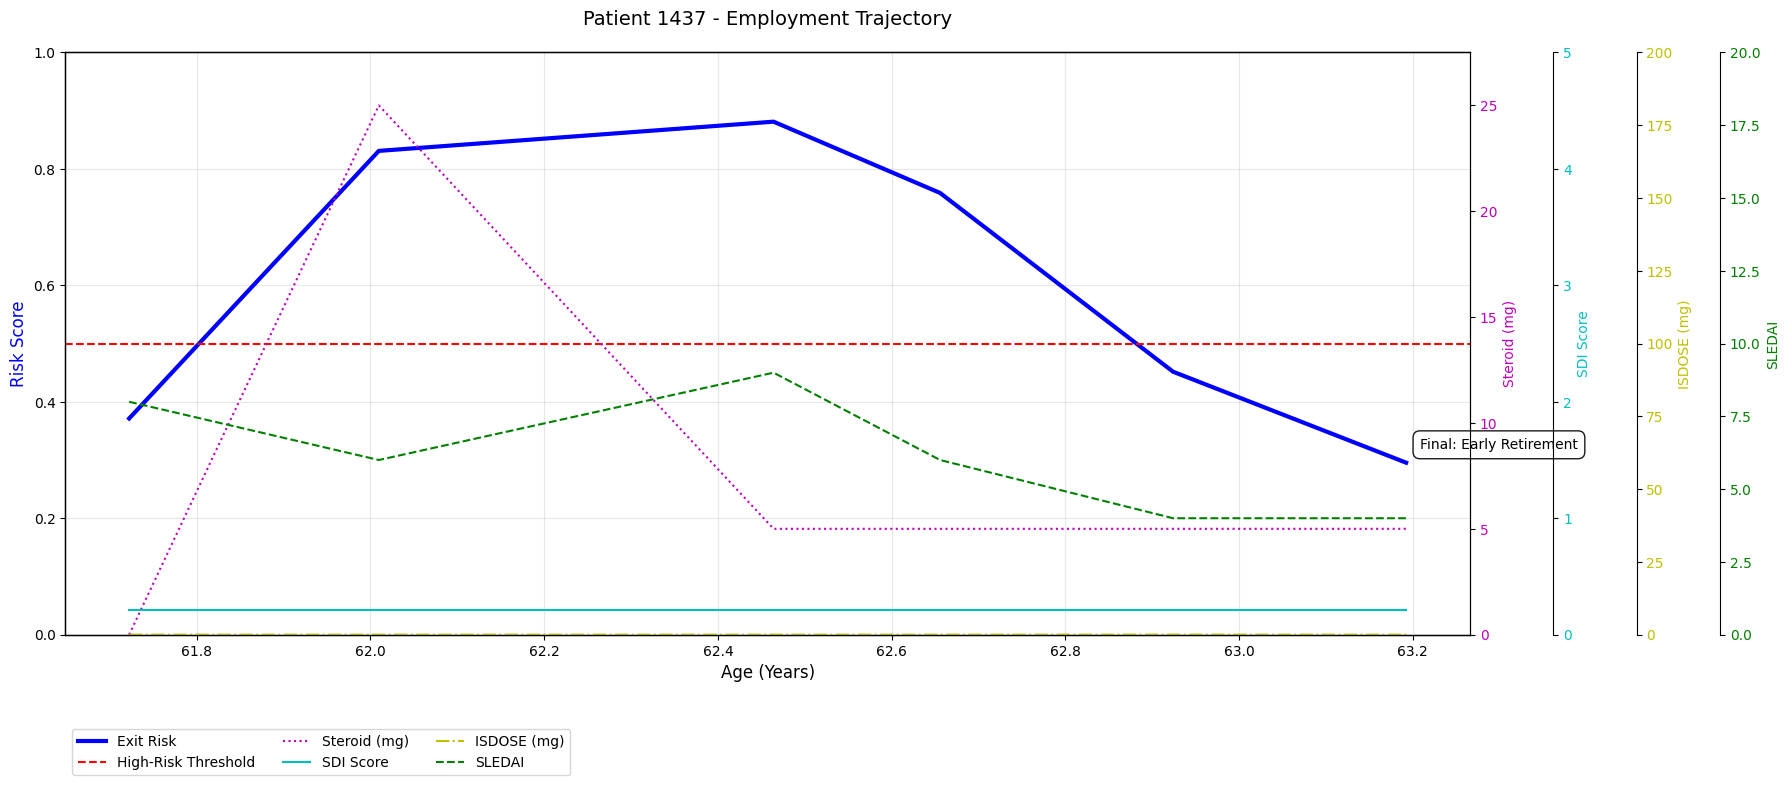

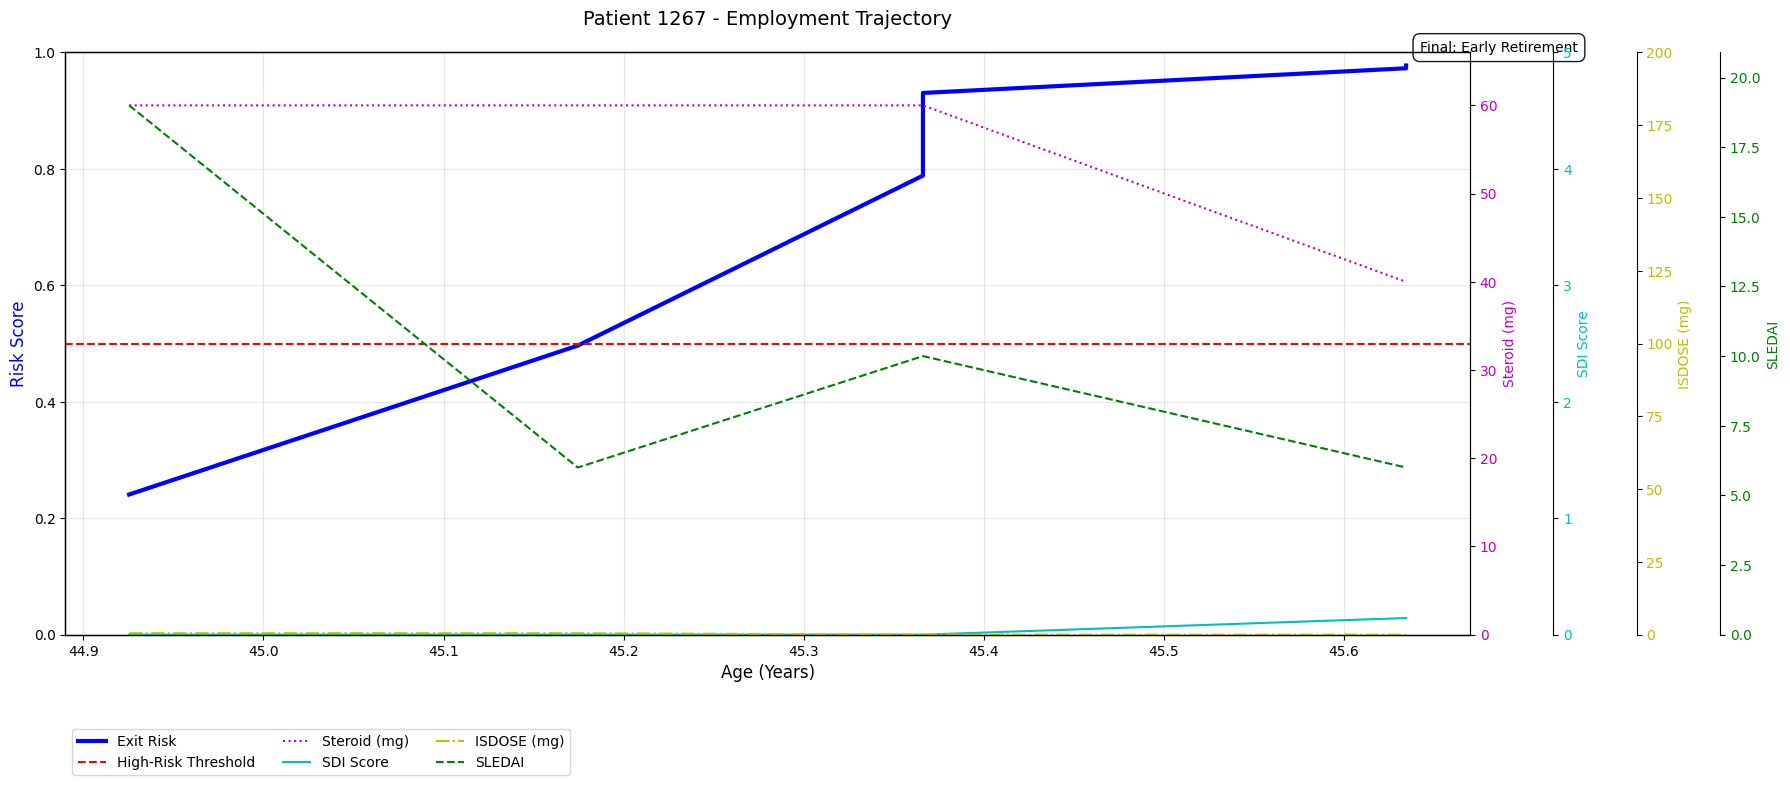

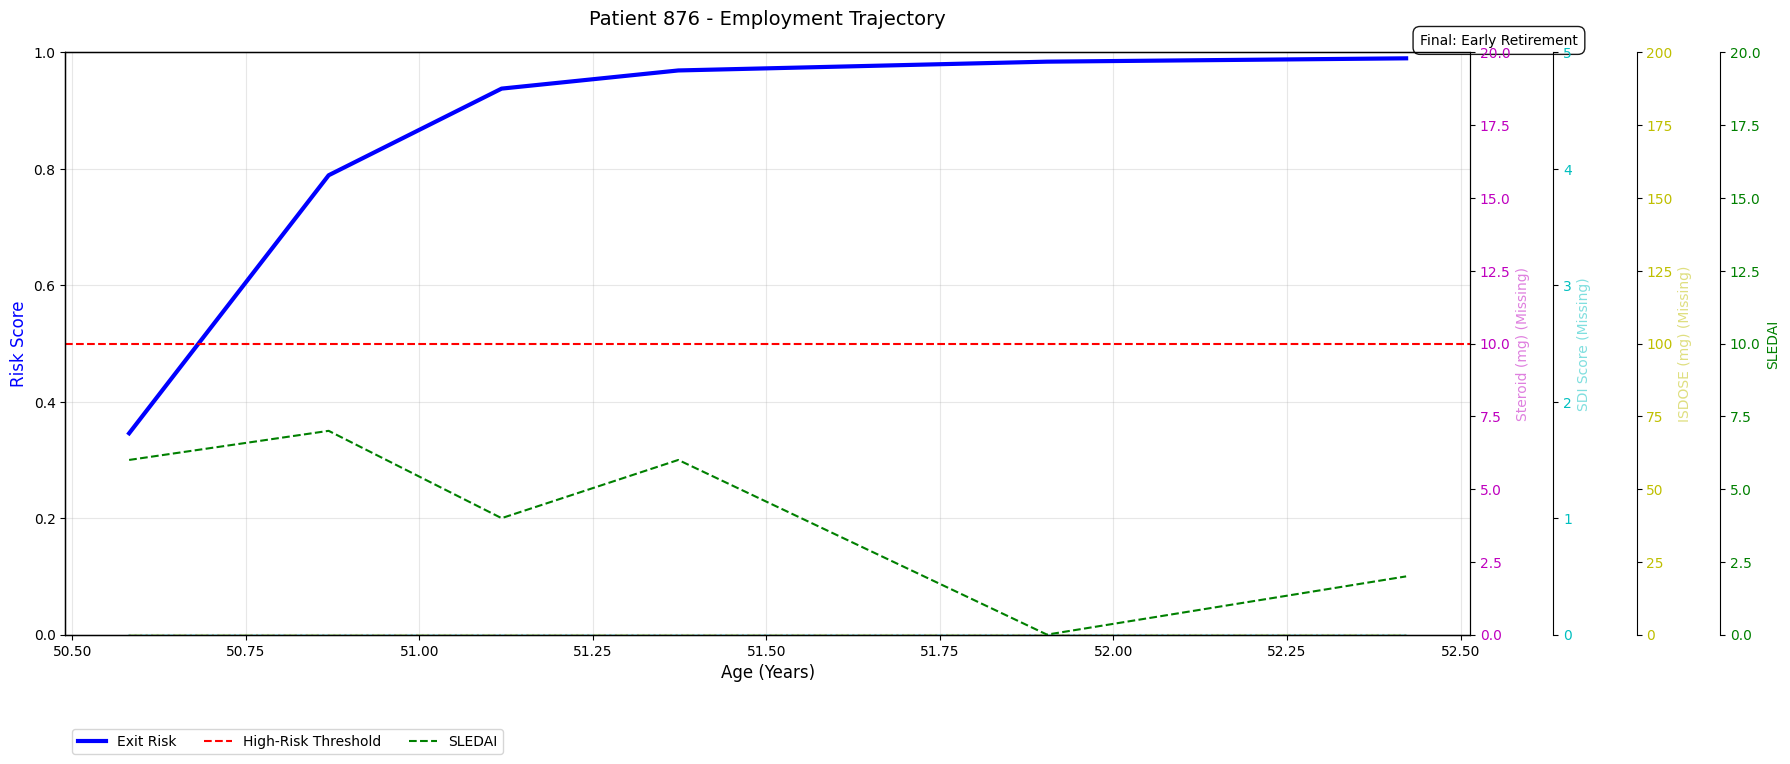

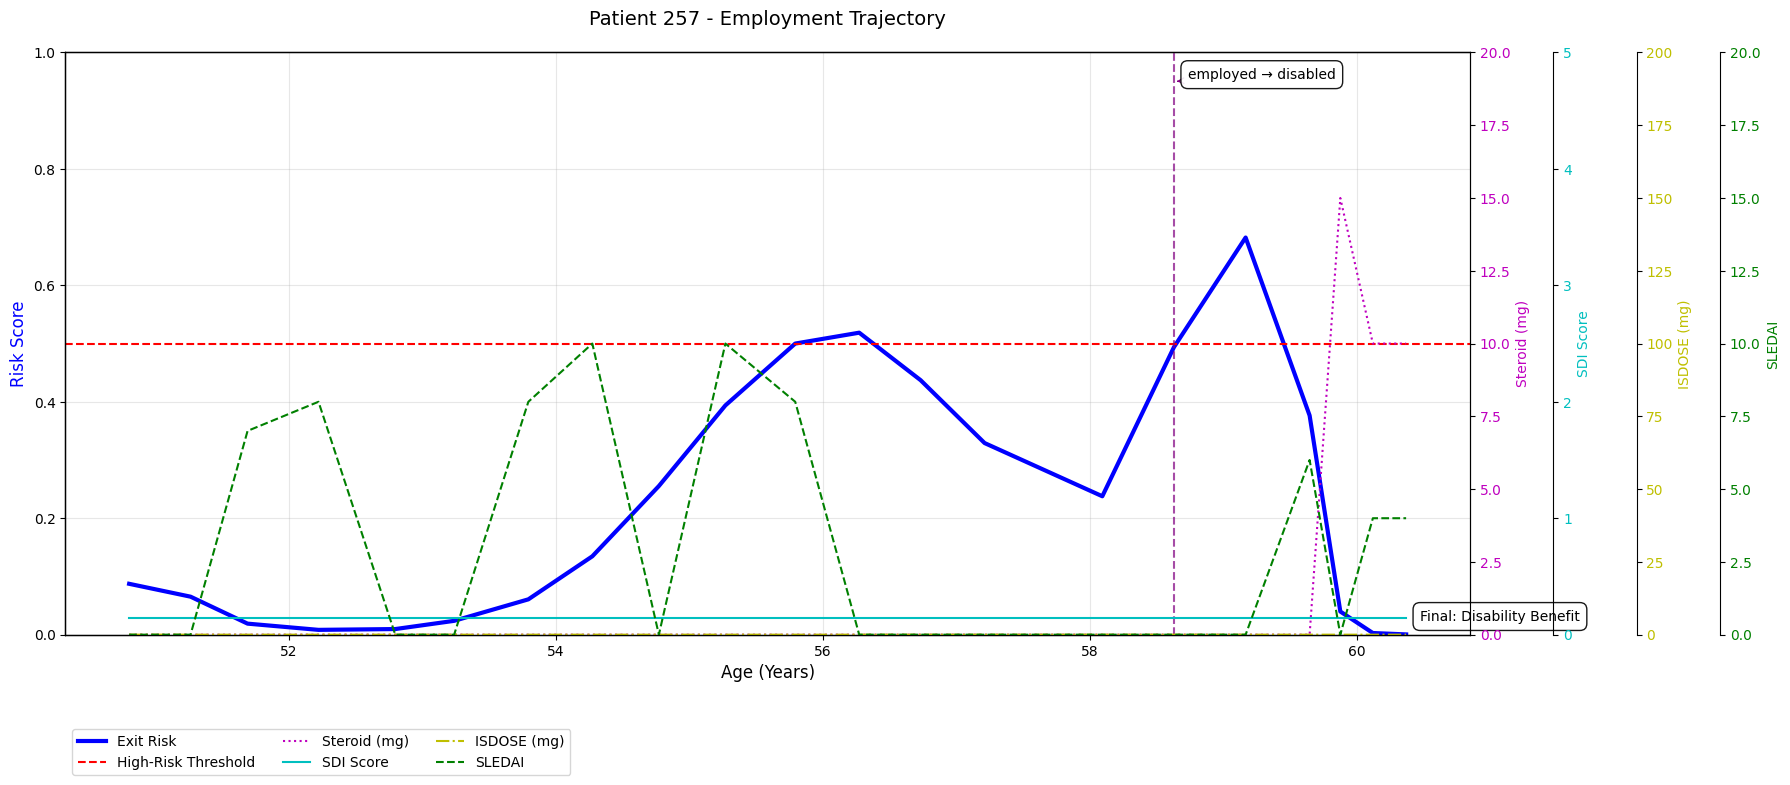

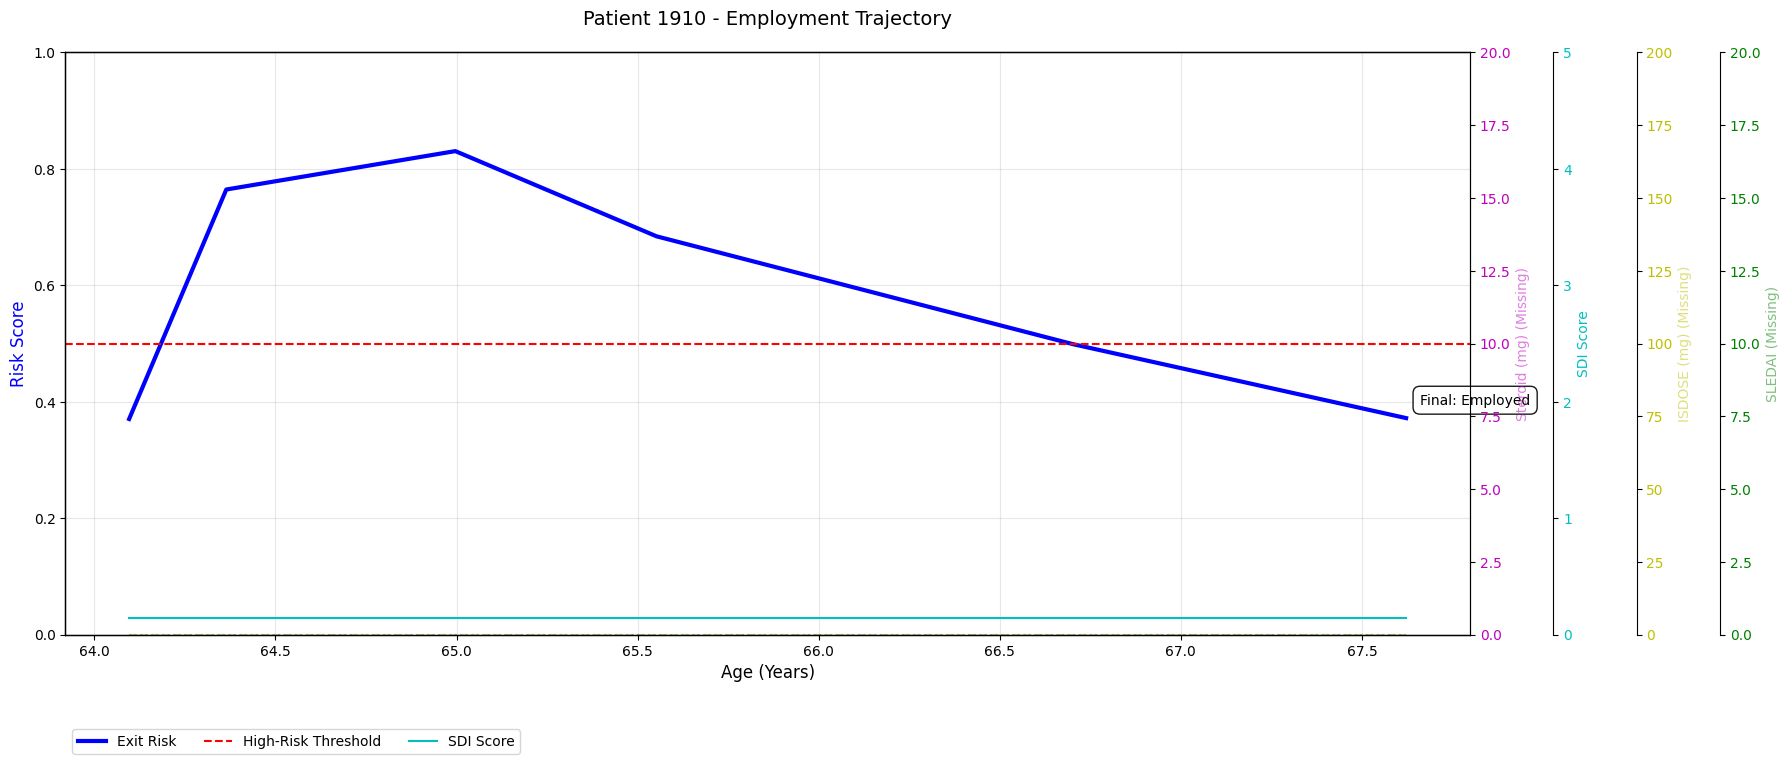

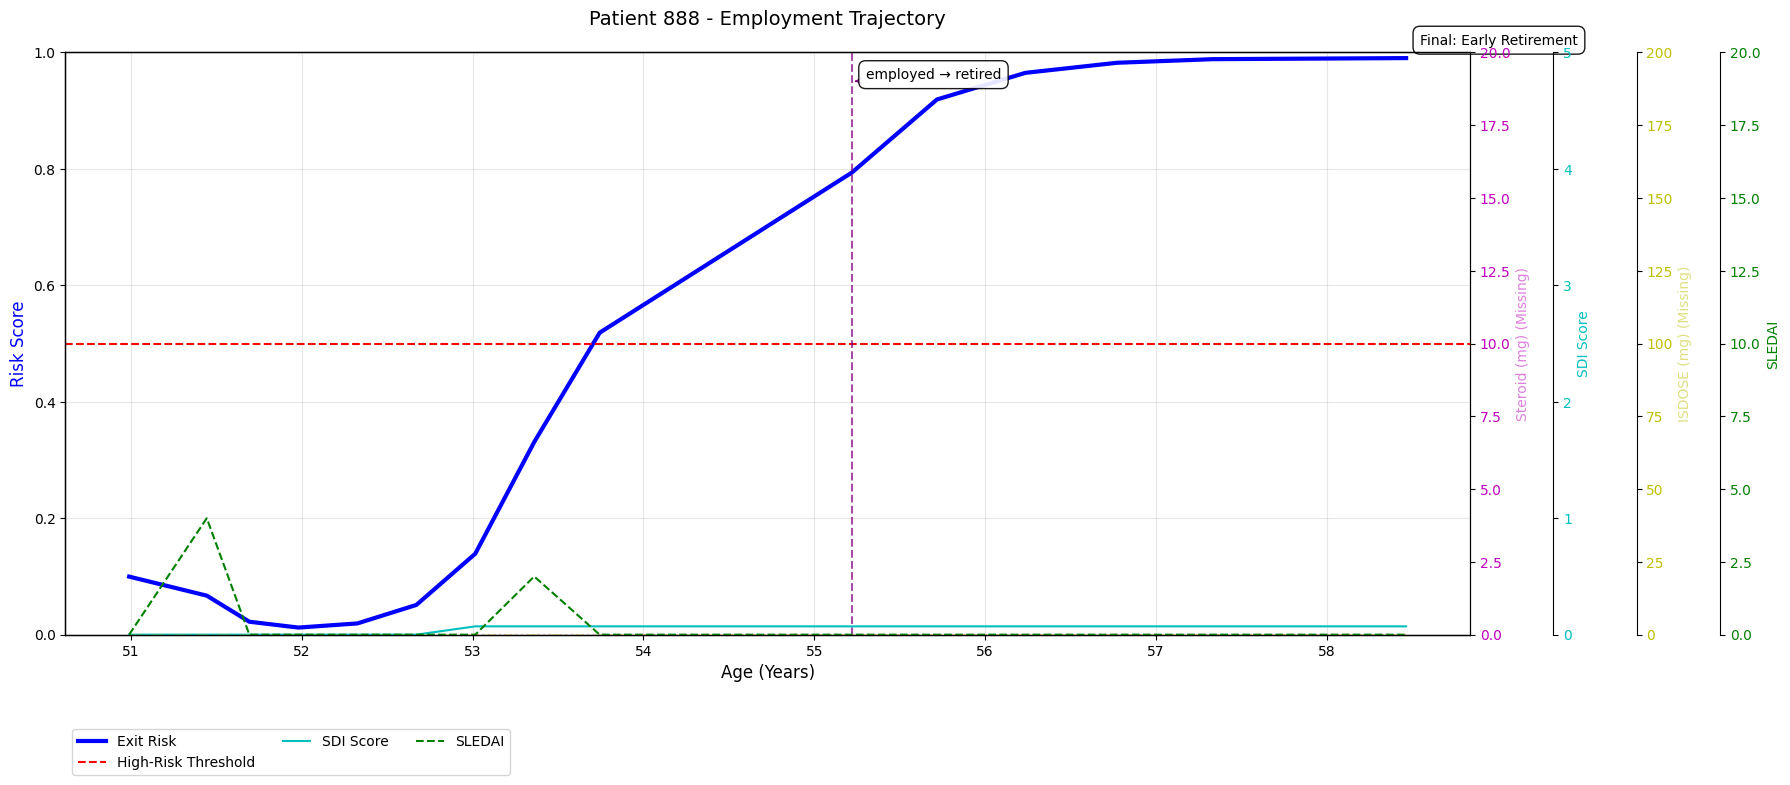

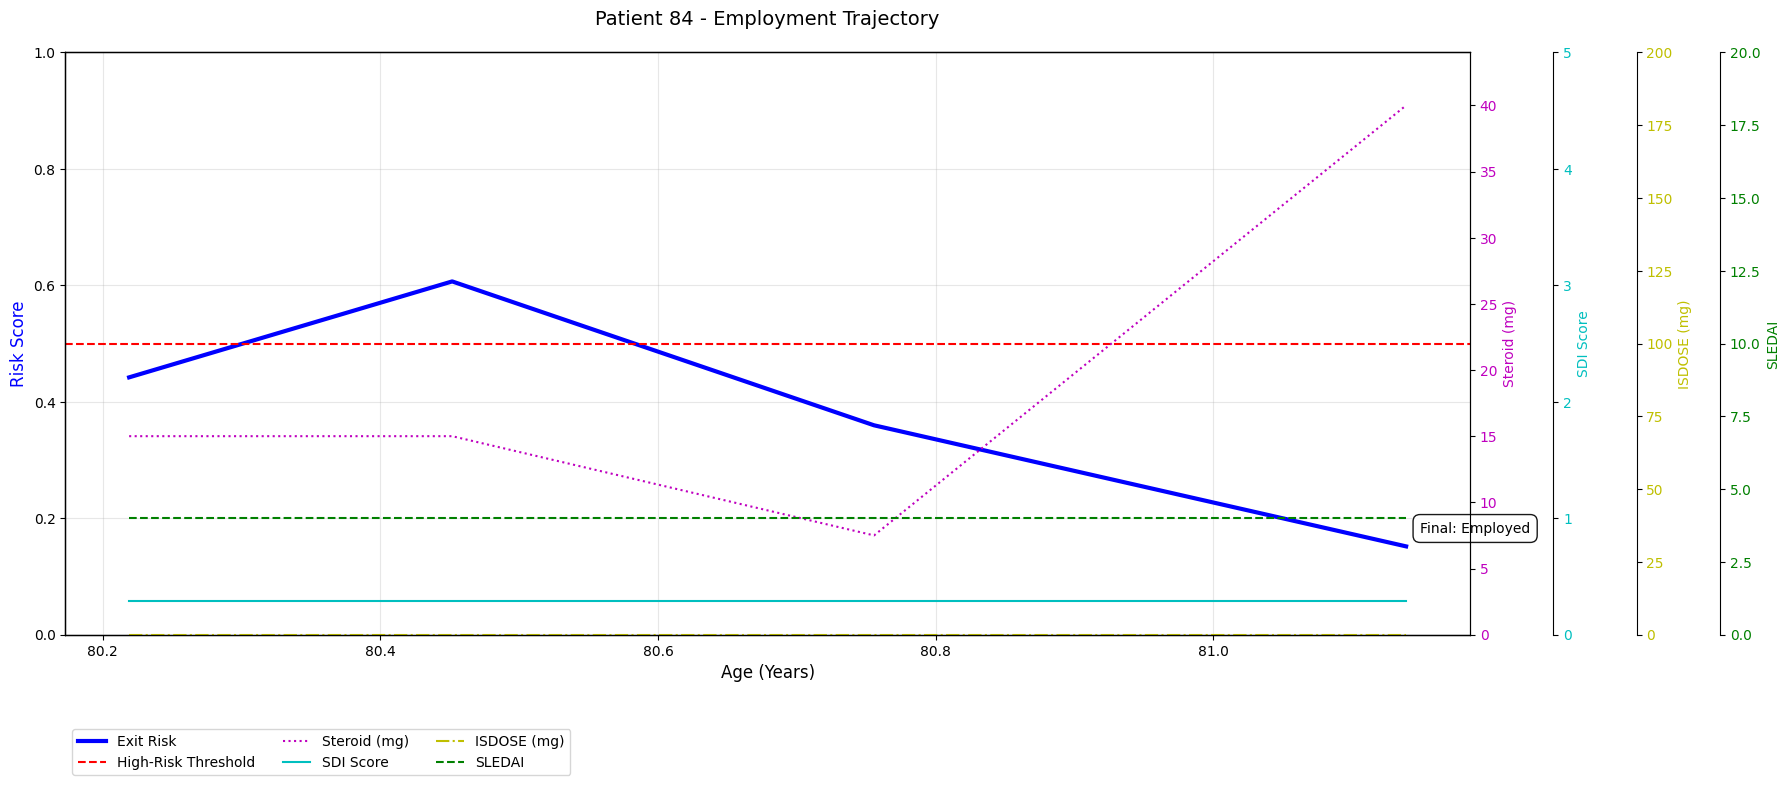

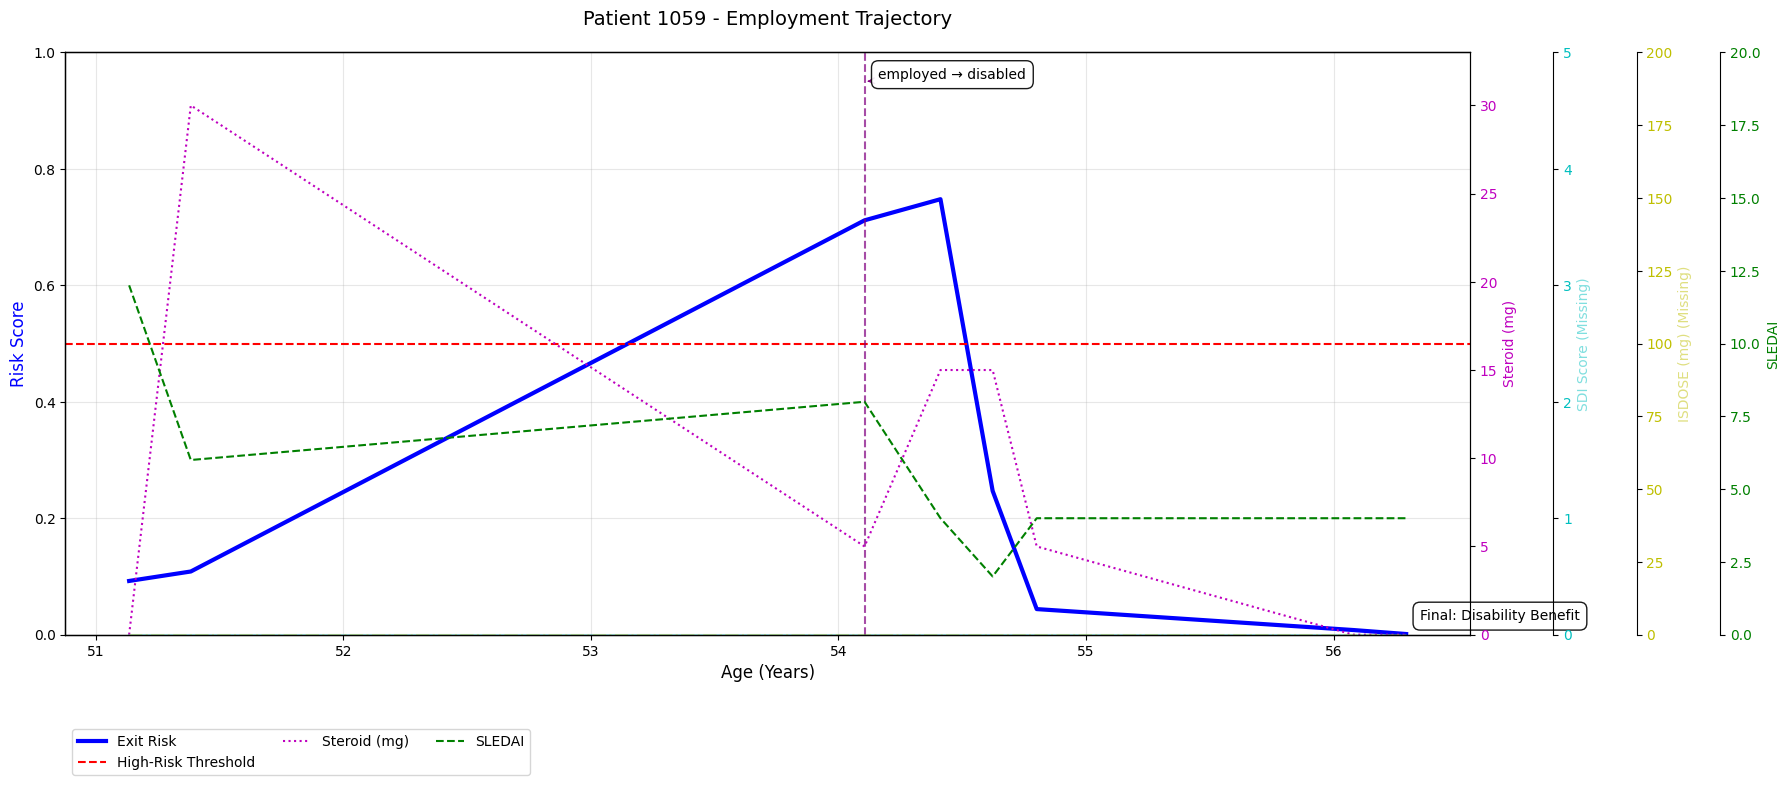

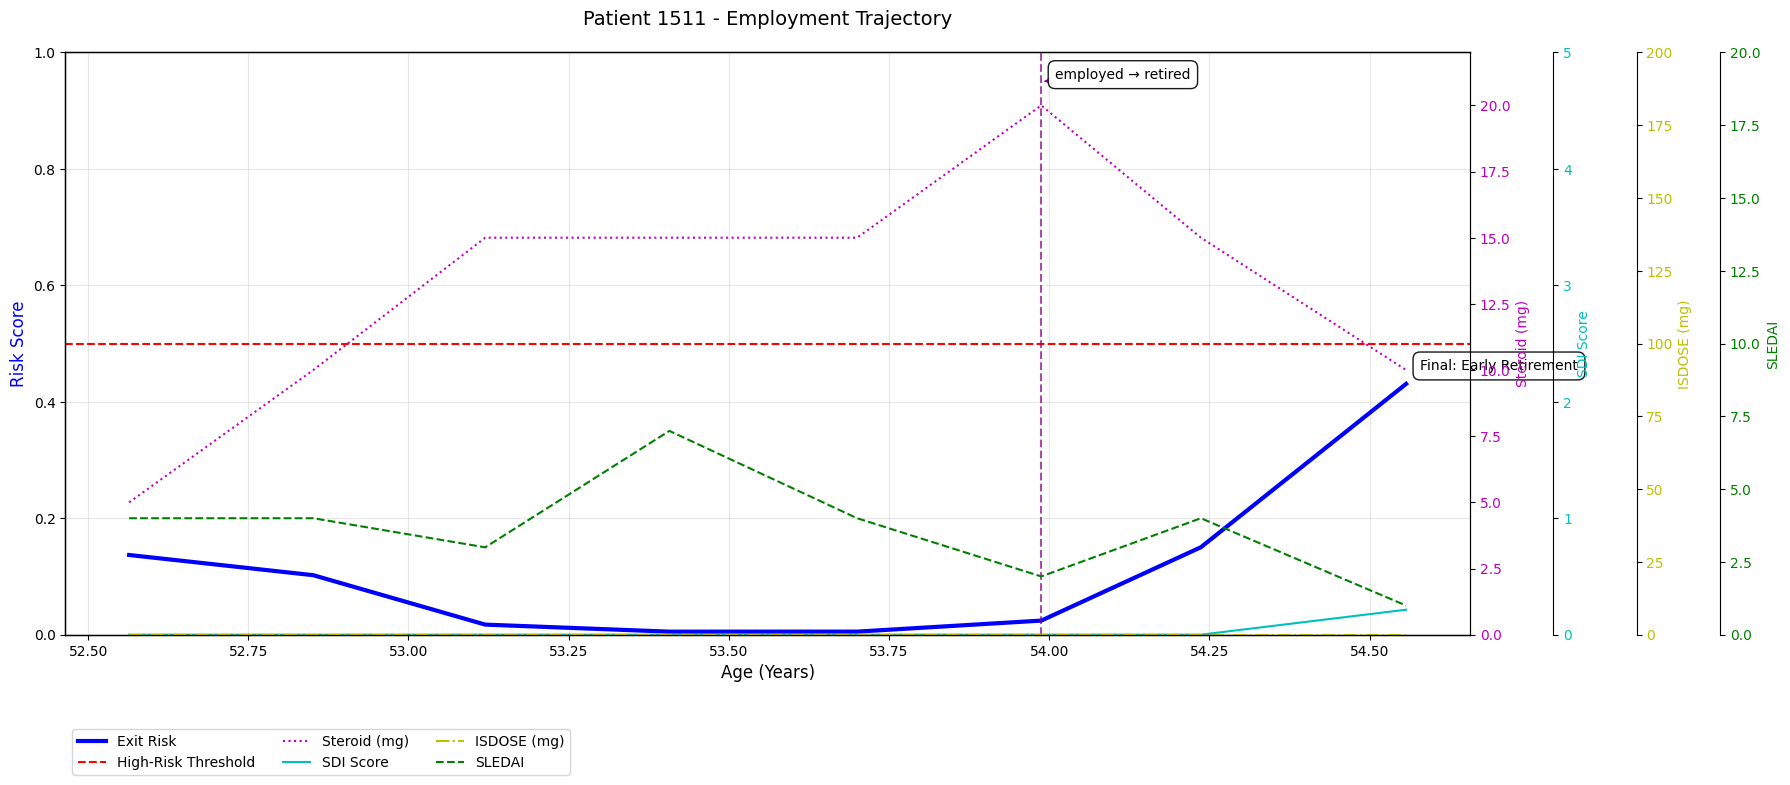

KeyboardInterrupt: 

In [118]:
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Enhanced trajectory plot with clear employment transition markers and guaranteed axis visibility"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age
    if 'BIRTHDT' in patient_data.columns:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    else:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['ASSDT'].min()).dt.days / 365.25
    
    # Get risk predictions
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = patient_data['Age'].values
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=(18, 8))
    
    # Plot risk score (always shown)
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Mark high-risk threshold
    threshold = risk_df['Threshold_Used'].iloc[0] if 'Threshold_Used' in risk_df.columns else 0.5
    ax1.axhline(y=threshold, color='r', linestyle='--', label='High-Risk Threshold')
    
    # Standard clinical markers with guaranteed display
    clinical_markers = {
        'Steroid': {
            'values': risk_df['Steroid_Dose'].fillna(0) if 'Steroid_Dose' in risk_df else np.zeros(len(risk_df)),
            'color': 'm',
            'style': ':',
            'label': 'Steroid (mg)',
            'scale': 1,
            'default_max': 20  # Default max steroid dose for scaling
        },
        'SDI': {
            'values': risk_df['SDI'].fillna(0) if 'SDI' in risk_df else np.zeros(len(risk_df)),
            'color': 'c',
            'style': '-',
            'label': 'SDI Score',
            'scale': 1,
            'default_max': 5  # SDI typically ranges 0-5
        },
        'Immunosuppressant': {
            'values': risk_df['Immunosuppressant'].fillna(0) if 'Immunosuppressant' in risk_df else np.zeros(len(risk_df)),
            'color': 'y',
            'style': '-.',
            'label': 'ISDOSE (mg)',
            'scale': 1,
            'default_max': 200  # Typical max ISDOSE
        },
        'SLEDAI': {
            'values': risk_df['SLEDAI'].fillna(0) if 'SLEDAI' in risk_df else np.zeros(len(risk_df)),
            'color': 'g',
            'style': '--',
            'label': 'SLEDAI',
            'scale': 1,
            'default_max': 20  # SLEDAI practical max
        }
    }
    
    # Create right axes for all clinical markers (always shown)
    axes_right = {}
    offset = 60
    
    for i, (marker_name, params) in enumerate(clinical_markers.items()):
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset*i))
        
        # Plot the line (even if all zeros)
        line = ax.plot(risk_df['Age'], params['values'], 
                      color=params['color'], 
                      linestyle=params['style'], 
                      label=params['label'])
        
        ax.set_ylabel(params['label'], color=params['color'])
        ax.tick_params(axis='y', labelcolor=params['color'])
        
        # Set consistent y-limits (0 to default_max)
        ax.set_ylim(0, params['default_max'])
        
        # Highlight if data is all zeros/missing
        if np.all(params['values'] == 0):
            line[0].set_alpha(0.3)  # Make line faint if no real data
            ax.set_ylabel(f"{params['label']} (Missing)", color=params['color'], alpha=0.5)
        else:
            # Auto-scale if we have real data
            clean_vals = params['values'][np.isfinite(params['values'])]
            if len(clean_vals) > 0:
                ymax = max(params['default_max'], np.max(clean_vals) * 1.1)
                ax.set_ylim(0, ymax)
        
        axes_right[marker_name] = ax
    
    # Enhanced employment transition markers
    if 'EMPf' in patient_data.columns:
        for i in range(1, len(patient_data)):
            if patient_data['EMPf'].iloc[i] != patient_data['EMPf'].iloc[i-1]:
                transition_age = patient_data['Age'].iloc[i]
                prev_status = patient_data['EMPf'].iloc[i-1]
                new_status = patient_data['EMPf'].iloc[i]
                
                # Add vertical line
                ax1.axvline(x=transition_age, color='purple', linestyle='--', alpha=0.7, linewidth=1.5)
                
                # Add label with arrow
                ax1.annotate(
                    f"{prev_status} → {new_status}",
                    xy=(transition_age, 0.95),
                    xytext=(10, 10),
                    textcoords='offset points',
                    ha='left',
                    va='top',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='purple')
                )
    
    # Highlight first high-risk flag if available
    if 'First_High_Risk_Date' in patient_data.columns and pd.notna(patient_data['First_High_Risk_Date'].iloc[0]):
        flag_age = (patient_data['First_High_Risk_Date'].iloc[0] - patient_data['BIRTHDT'].iloc[0]).days/365.25
        ax1.axvline(x=flag_age, color='darkgreen', linestyle=':', linewidth=2)
        ax1.text(flag_age, 0.9, 'First Risk Flag', rotation=90, 
                ha='right', va='top', color='darkgreen')
    
    # Final outcome annotation
    if 'end_state' in patient_data.columns:
        final_age = patient_data['Age'].iloc[-1]
        ax1.annotate(
            f"Final: {patient_data['end_state'].iloc[-1]}",
            xy=(final_age, risk_df['Risk_Score'].iloc[-1]),
            xytext=(10, 10),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9)
        )
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for marker_name, ax in axes_right.items():
        lines, labels = ax.get_legend_handles_labels()
        # Only include in legend if we have real data
        if not np.all(clinical_markers[marker_name]['values'] == 0):
            lines_right.extend(lines)
            labels_right.extend(labels)
    
    if lines_right:  # Only add if we have right axis data
        ax1.legend(lines1 + lines_right, labels1 + labels_right, 
                  loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3)
    else:
        ax1.legend(lines1, labels1, loc='upper left', bbox_to_anchor=(0, -0.15))
    
    plt.title(f'Patient {pid} - Employment Trajectory', fontsize=14, pad=20)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

# Convert date columns to datetime if they're strings
date_cols = ['ASSDT', 'BIRTHDT', 'First_High_Risk_Date', 'Final_Outcome_Date']
for col in date_cols:
    if col in data.columns and data[col].dtype == object:
        data[col] = pd.to_datetime(data[col], errors='coerce')
    if col in high_risk_df.columns and high_risk_df[col].dtype == object:
        high_risk_df[col] = pd.to_datetime(high_risk_df[col], errors='coerce')
        
# Visualize example cases with age on x-axis
if not high_risk_df.empty:
    print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
    for pid in high_risk_df['PTNO'].sample(min(20, len(high_risk_df)), random_state=365):
        plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)
else:
    print("No high-risk patients to visualize.")

# NEW RISK